**Suppliers**

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from pathlib import Path

In [17]:
file_path = Path.cwd().parent.parent/"Excel"/"2_Suppliers.xlsx"
df = pd.read_excel(file_path)
df

,Supplier_ID,Supplier_Name,Region,Lead_Time_Days,Reliability_Score
0,S100,Supplier 1,South,21,55.46
1,S101,Supplier 2,South,27,94.38
2,S102,Supplier 3,East,7,61.56
3,S103,Supplier 4,East,24,89.58
4,S104,Supplier 5,West,26,82.19
...,...,...,...,...,...
96,S196,Supplier 97,East,20,80.50
97,S197,Supplier 98,North,6,55.98
98,S198,Supplier 99,West,19,-10.00
99,S199,Supplier 100,South,6,56.82


In [18]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Supplier_ID        101 non-null    object 
 1   Supplier_Name      101 non-null    object 
 2   Region             101 non-null    object 
 3   Lead_Time_Days     101 non-null    int64  
 4   Reliability_Score  101 non-null    float64
dtypes: float64(1), int64(1), object(3)
memory usage: 4.1+ KB


In [19]:
# Capitalize, Trimming and Consistent null values
columns = ["Supplier_ID", "Supplier_Name", "Region"]
for col in columns:
    df[col] = df[col].str.capitalize()
    df[col] = df[col].str.strip()
nulls = ["N/a", "Na", "Null", "Unknown", ""]
df.replace(nulls, np.nan, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Supplier_ID        100 non-null    object 
 1   Supplier_Name      100 non-null    object 
 2   Region             101 non-null    object 
 3   Lead_Time_Days     101 non-null    int64  
 4   Reliability_Score  101 non-null    float64
dtypes: float64(1), int64(1), object(3)
memory usage: 4.1+ KB


In [20]:
# Dropping duplicates except nulls
mask = df["Supplier_ID"].notna()
df = pd.concat([
    df[mask].drop_duplicates(subset=["Supplier_ID"], keep="first"),
    df[~mask]
]).sort_index()
df.reset_index(drop=True, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Supplier_ID        99 non-null     object 
 1   Supplier_Name      99 non-null     object 
 2   Region             100 non-null    object 
 3   Lead_Time_Days     100 non-null    int64  
 4   Reliability_Score  100 non-null    float64
dtypes: float64(1), int64(1), object(3)
memory usage: 4.0+ KB


In [21]:
# Replacing null values in Supplier ID
df["Supplier_ID"].isna().sum()
for i in range(len(df)):
    value = df.loc[i, "Supplier_ID"]
    if not pd.notna(value):
        df.loc[i, "Supplier_ID"] = f"S{100+i}"
df["Supplier_ID"].isna().sum()
df["Supplier_ID"].duplicated().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Supplier_ID        100 non-null    object 
 1   Supplier_Name      99 non-null     object 
 2   Region             100 non-null    object 
 3   Lead_Time_Days     100 non-null    int64  
 4   Reliability_Score  100 non-null    float64
dtypes: float64(1), int64(1), object(3)
memory usage: 4.0+ KB


In [22]:
# Replacing null values in Supplier Name
df["Supplier_Name"].isna().sum()
df["Supplier_Name"].head()
mask = df["Supplier_Name"].isna()
for i in range(len(df)):
    value = df.loc[i, "Supplier_Name"]
    if not pd.notna(value):
        df.loc[i, "Supplier_Name"] = f"Supplier {i+1}"
df["Supplier_Name"].isna().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Supplier_ID        100 non-null    object 
 1   Supplier_Name      100 non-null    object 
 2   Region             100 non-null    object 
 3   Lead_Time_Days     100 non-null    int64  
 4   Reliability_Score  100 non-null    float64
dtypes: float64(1), int64(1), object(3)
memory usage: 4.0+ KB


In [23]:
# Checking if errors in Region
df["Region"].unique()

array(['South', 'East', 'West', 'North'], dtype=object)

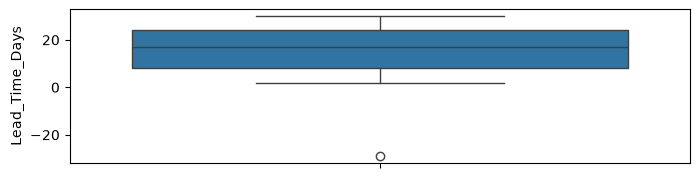

count    100.000000
mean      15.760000
std        9.841286
min      -29.000000
25%        8.000000
50%       17.000000
75%       24.000000
max       30.000000
Name: Lead_Time_Days, dtype: float64

In [ ]:
# Checking for negatives or outliers
plt.figure(figsize=(8,2))
sb.boxplot(df["Lead_Time_Days"])
plt.show()
df["Lead_Time_Days"].describe()

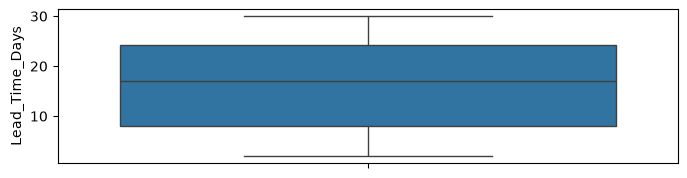

In [ ]:
# Correction of negatives
df.loc[df["Lead_Time_Days"] < 0, "Lead_Time_Days"] *= -1
plt.figure(figsize=(8,2))
sb.boxplot(df["Lead_Time_Days"])
plt.show()

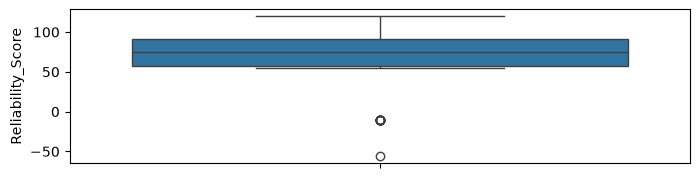

In [ ]:
# Checking for negatives or outliers
plt.figure(figsize=(8,2))
sb.boxplot(df["Reliability_Score"])
plt.show()

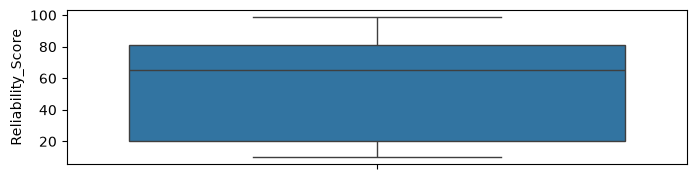

count    100.000000
mean      57.688200
std       30.134182
min       10.000000
25%       20.000000
50%       65.355000
75%       81.245000
max       98.760000
Name: Reliability_Score, dtype: float64

In [ ]:
# Correction of negatives and outliers
df.loc[df["Reliability_Score"] < 0, "Reliability_Score"] *= -1
df.loc[df["Reliability_Score"] > 100, "Reliability_Score"] %= 100
plt.figure(figsize=(8,2))
sb.boxplot(df["Reliability_Score"])
plt.show()
df["Reliability_Score"].describe()

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Supplier_ID        100 non-null    object 
 1   Supplier_Name      100 non-null    object 
 2   Region             100 non-null    object 
 3   Lead_Time_Days     100 non-null    int64  
 4   Reliability_Score  100 non-null    float64
dtypes: float64(1), int64(1), object(3)
memory usage: 4.0+ KB


In [29]:
df.to_csv("../../Data/Cleaned/Suppliers.csv", index=False)